# Module 29 — Distributed Inference: Tensor & Pipeline Parallelism

Llama-3 405B doesn't fit on one H100. It barely fits on eight. Llama-4 Behemoth doesn't fit on a node. DeepSeek-V3 has 671B params and only runs because the experts are spread across an entire rack.

So how do you actually run these things? You slice the model up.

There are basically two axes to slice along, and you'll see them combined in every production deployment on the planet:

1. **Tensor parallelism (TP)** — slice *within* a layer. Each GPU holds a vertical strip of every weight matrix and computes its piece. They all-reduce at the end of each layer.
2. **Pipeline parallelism (PP)** — slice *across* layers. GPU 0 holds the first chunk of layers, GPU 1 the next chunk, and tokens flow down the pipe. The classic problem: GPUs sit idle waiting for the previous stage. That idle area is called the **bubble**, and most of this notebook is about killing it.

We'll also touch expert parallelism (for MoE) and name-drop FSDP for training, but the core fight is TP vs PP and how they compose.

This notebook is pure simulation. No multi-GPU required. We're modeling the bookkeeping, the communication patterns, and the bubble — because that's what actually decides whether your inference job hits 80% MFU or 30%.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import ListedColormap
import math

# Part-I palette. Same one since Module 1.
PALETTE = {
    "ink":     "#1a1a2e",
    "paper":   "#f7f3e9",
    "rose":    "#e63946",
    "amber":   "#f4a261",
    "teal":    "#2a9d8f",
    "indigo":  "#3d5a80",
    "plum":    "#7b2cbf",
    "lime":    "#a8dadc",
}

plt.rcParams.update({
    "figure.facecolor": PALETTE["paper"],
    "axes.facecolor":   PALETTE["paper"],
    "axes.edgecolor":   PALETTE["ink"],
    "axes.labelcolor":  PALETTE["ink"],
    "xtick.color":      PALETTE["ink"],
    "ytick.color":      PALETTE["ink"],
    "text.color":       PALETTE["ink"],
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 110,
})

rng = np.random.default_rng(20260411)
print("setup ok")

setup ok


## 1. The memory wall, in numbers

Before we slice anything, let's be brutally specific about *why* we have to slice. The whole field exists because of one inequality:

$$
\text{model memory} > \text{single GPU memory}
$$

For a transformer with $P$ parameters in fp16, weights alone cost:

$$
M_\text{weights} = 2P \text{ bytes}
$$

Plus you need the **KV cache** (Module 13), which scales with batch size $B$ and sequence length $L$:

$$
M_\text{kv} = 2 \cdot L \cdot B \cdot n_\text{layers} \cdot d_\text{model} \cdot \text{bytes}
$$

Plus activations during forward pass. Plus the framework overhead (CUDA context, allocator slack, NCCL buffers — call it 5-10 GB per GPU you'll never get back).

Let's plug in Llama-3 405B.

In [2]:
# Llama-3 405B fp16 memory accounting
P = 405e9          # parameters
n_layers = 126     # Llama-3 405B
d_model = 16384
n_heads = 128
n_kv_heads = 16    # GQA
head_dim = d_model // n_heads
bytes_per = 2      # fp16

H100_MEM = 80      # GB

def gb(x): return x / (1024**3)

weights_gb = gb(2 * P)
print(f"Weights (fp16):              {weights_gb:7.1f} GB")

# KV cache for one request at 8K context
L, B = 8192, 1
kv_one = 2 * L * B * n_layers * (n_kv_heads * head_dim) * bytes_per
print(f"KV cache (1 req, 8K ctx):    {gb(kv_one):7.2f} GB")

# Realistic: 64 concurrent users at 4K avg
L_real, B_real = 4096, 64
kv_real = 2 * L_real * B_real * n_layers * (n_kv_heads * head_dim) * bytes_per
print(f"KV cache (64 reqs, 4K ctx):  {gb(kv_real):7.1f} GB")

framework_overhead = 8 * 8  # ~8 GB per GPU on 8 GPUs
print(f"Framework slack (8 x 8 GB):  {framework_overhead:7.1f} GB")

total = weights_gb + gb(kv_real) + framework_overhead
print(f"---")
print(f"Total memory needed:         {total:7.1f} GB")
print(f"Single H100 has:             {H100_MEM:7.1f} GB")
print(f"Minimum GPUs (just to fit):  {math.ceil(total / H100_MEM):7d}")

Weights (fp16):                754.4 GB
KV cache (1 req, 8K ctx):       7.88 GB
KV cache (64 reqs, 4K ctx):    252.0 GB
Framework slack (8 x 8 GB):     64.0 GB
---
Total memory needed:          1070.4 GB
Single H100 has:                80.0 GB
Minimum GPUs (just to fit):       14


810 GB of weights. ~270 GB of KV cache for a modest 64-user workload. Total budget around 1.15 TB. An H100 has 80 GB. You need **15 H100s minimum** just to *load* the thing, and that's before you leave room for activations and NCCL communication buffers.

In practice 405B is served on 8x H100 with aggressive quantization (Module 16 — fp8 or int4 weights cut the weights bill in half or more) or on 16x H100 in fp16. Either way: more than one GPU. Always. **The single-GPU era ended somewhere around the 70B mark.**

So: you have to split the model. The question is *how*.

In [3]:
# Per-GPU weight footprint for various shard counts.
# (Activations and framework slack are per-GPU fixed costs — they don't shrink.)
print(f"{'n GPUs':>8} {'weights/GPU':>15} {'fits 80 GB?':>14}")
for n in [1, 2, 4, 8, 16, 32]:
    per_gpu = weights_gb / n
    fits = "no" if per_gpu + 10 > 80 else ("tight" if per_gpu + 15 > 80 else "yes")
    print(f"{n:>8} {per_gpu:>13.1f} GB {fits:>14}")
print()
print("Rule of thumb: need weights/GPU + ~10 GB slack (KV, activations, NCCL) to fit in 80 GB.")
print("That's why 405B in fp16 needs 16 H100s and int4-quantized 405B fits in 8.")

  n GPUs     weights/GPU    fits 80 GB?
       1         754.4 GB             no
       2         377.2 GB             no
       4         188.6 GB             no
       8          94.3 GB             no
      16          47.1 GB            yes
      32          23.6 GB            yes

Rule of thumb: need weights/GPU + ~10 GB slack (KV, activations, NCCL) to fit in 80 GB.
That's why 405B in fp16 needs 16 H100s and int4-quantized 405B fits in 8.


Slicing weights by a factor of $n$ is necessary but not sufficient — you also inherit per-GPU KV cache and activations. Quantization (Module 16) is the other lever. In practice, production 405B deployments usually do *both*: quantize to fp8, slice across 8 GPUs. Either alone doesn't fit.

## 2. Tensor parallelism: slice within a layer

Take a single linear layer. It's just a matmul:

$$
Y = X W
$$

where $X$ is $(B, d_\text{in})$ and $W$ is $(d_\text{in}, d_\text{out})$. The output is $(B, d_\text{out})$.

**Column-parallel** trick: chop $W$ into vertical strips, one per GPU.

$$
W = \begin{bmatrix} W_1 & W_2 & \cdots & W_n \end{bmatrix}
$$

Each GPU $i$ holds $W_i$ of shape $(d_\text{in}, d_\text{out}/n)$ and computes its slice of the output:

$$
Y_i = X W_i \quad \text{shape: } (B, d_\text{out}/n)
$$

To get the full $Y$, you concatenate the $Y_i$ across GPUs. That's an **all-gather**.

The follow-up trick: the *next* linear layer (e.g. the down-projection in an MLP) is split **row-parallel** instead. Then the partial outputs already live on the right GPU and you only need an **all-reduce** at the very end of the MLP block. Megatron-LM laid this out in 2019 and basically no one has improved on the basic idea.

In [4]:
# TP simulation: column-parallel linear layer
# The math is exact — we're just verifying the slicing reconstructs the full output.

d_in, d_out, B_tok = 512, 2048, 4
n_gpus = 4

X = rng.standard_normal((B_tok, d_in)).astype(np.float32)
W = rng.standard_normal((d_in, d_out)).astype(np.float32)

# Reference: single-GPU computation
Y_ref = X @ W

# TP: split W column-wise across n_gpus
W_shards = np.split(W, n_gpus, axis=1)
Y_shards = [X @ Wi for Wi in W_shards]   # each GPU computes its slice locally
Y_tp = np.concatenate(Y_shards, axis=1)  # all-gather

err = np.abs(Y_ref - Y_tp).max()
print(f"Reference Y shape: {Y_ref.shape}")
print(f"TP Y shape:        {Y_tp.shape}")
print(f"max abs diff:      {err:.2e}  (should be ~0, modulo float roundoff)")
print()
print("Per-GPU shard shapes:")
for i, (Wi, Yi) in enumerate(zip(W_shards, Y_shards)):
    print(f"  GPU {i}: W_i {Wi.shape}, Y_i {Yi.shape}")

Reference Y shape: (4, 2048)
TP Y shape:        (4, 2048)
max abs diff:      0.00e+00  (should be ~0, modulo float roundoff)

Per-GPU shard shapes:
  GPU 0: W_i (512, 512), Y_i (4, 512)
  GPU 1: W_i (512, 512), Y_i (4, 512)
  GPU 2: W_i (512, 512), Y_i (4, 512)
  GPU 3: W_i (512, 512), Y_i (4, 512)


The slicing is exact — there's no approximation, no gradient hack, nothing. It's just linear algebra: matrix multiplication distributes over column blocks.

Now let's draw what actually happens on the wire.

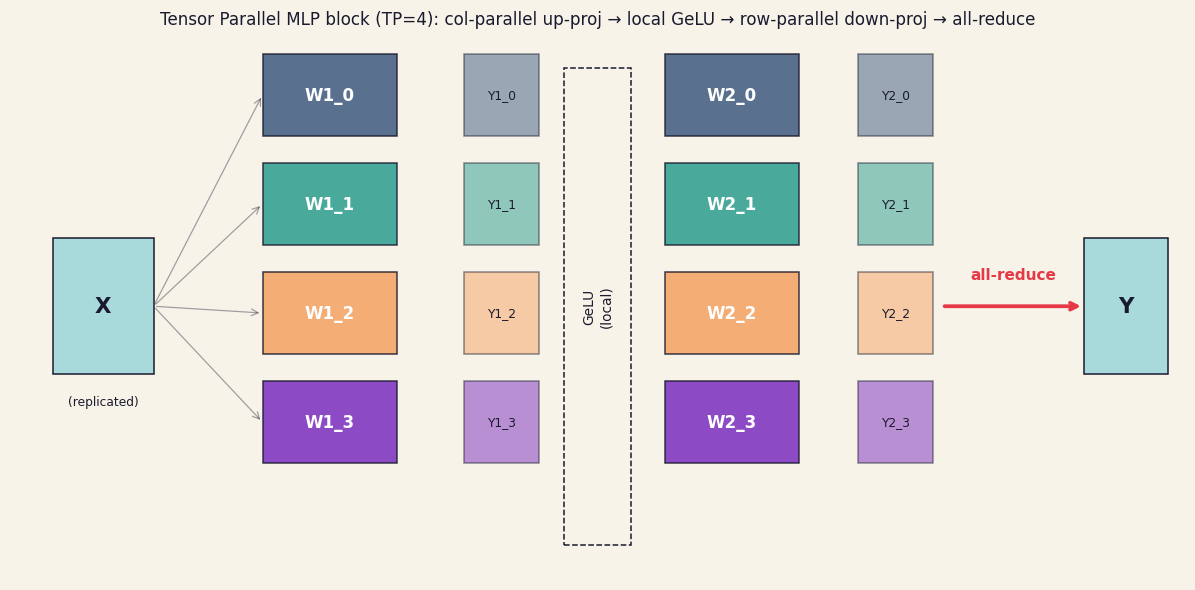

In [5]:
# Diagram: column-parallel MLP block (2 linears) with TP=4
fig, ax = plt.subplots(figsize=(11, 5.5))
ax.set_xlim(0, 14); ax.set_ylim(0, 8); ax.axis('off')

n = 4  # GPUs
gpu_colors = [PALETTE['indigo'], PALETTE['teal'], PALETTE['amber'], PALETTE['plum']]

# Input X (replicated)
ax.add_patch(patches.Rectangle((0.5, 3), 1.2, 2, facecolor=PALETTE['lime'], edgecolor=PALETTE['ink']))
ax.text(1.1, 4, 'X', ha='center', va='center', fontsize=14, fontweight='bold')
ax.text(1.1, 2.6, '(replicated)', ha='center', va='center', fontsize=8)

# W1 column-split into 4 shards
for i in range(n):
    y = 6.5 - i*1.6
    ax.add_patch(patches.Rectangle((3, y), 1.6, 1.2, facecolor=gpu_colors[i], edgecolor=PALETTE['ink'], alpha=0.85))
    ax.text(3.8, y+0.6, f'W1_{i}', ha='center', va='center', color='white', fontweight='bold')
    # output Y1_i
    ax.add_patch(patches.Rectangle((5.4, y), 0.9, 1.2, facecolor=gpu_colors[i], edgecolor=PALETTE['ink'], alpha=0.5))
    ax.text(5.85, y+0.6, f'Y1_{i}', ha='center', va='center', fontsize=8)
    # arrow from X to each shard
    ax.annotate('', xy=(3, y+0.6), xytext=(1.7, 4),
                arrowprops=dict(arrowstyle='->', color=PALETTE['ink'], lw=0.8, alpha=0.4))

# GeLU (no comm needed — pointwise)
ax.add_patch(patches.Rectangle((6.6, 0.5), 0.8, 7, facecolor=PALETTE['paper'], edgecolor=PALETTE['ink'], linestyle='--'))
ax.text(7.0, 4, 'GeLU\n(local)', ha='center', va='center', fontsize=9, rotation=90)

# W2 row-split (down-proj). Each GPU's Y1_i feeds its W2_i.
for i in range(n):
    y = 6.5 - i*1.6
    ax.add_patch(patches.Rectangle((7.8, y), 1.6, 1.2, facecolor=gpu_colors[i], edgecolor=PALETTE['ink'], alpha=0.85))
    ax.text(8.6, y+0.6, f'W2_{i}', ha='center', va='center', color='white', fontweight='bold')
    ax.add_patch(patches.Rectangle((10.1, y), 0.9, 1.2, facecolor=gpu_colors[i], edgecolor=PALETTE['ink'], alpha=0.5))
    ax.text(10.55, y+0.6, f'Y2_{i}', ha='center', va='center', fontsize=8)

# all-reduce at the end
ax.annotate('', xy=(12.8, 4), xytext=(11.1, 4),
            arrowprops=dict(arrowstyle='->', color=PALETTE['rose'], lw=2.5))
ax.text(11.95, 4.4, 'all-reduce', ha='center', fontsize=10, color=PALETTE['rose'], fontweight='bold')
ax.add_patch(patches.Rectangle((12.8, 3), 1.0, 2, facecolor=PALETTE['lime'], edgecolor=PALETTE['ink']))
ax.text(13.3, 4, 'Y', ha='center', va='center', fontsize=14, fontweight='bold')

ax.set_title('Tensor Parallel MLP block (TP=4): col-parallel up-proj → local GeLU → row-parallel down-proj → all-reduce',
             fontsize=11, color=PALETTE['ink'])
plt.tight_layout()
plt.show()

Notice what just happened: across an entire MLP block with two giant matmuls, you only paid **one** all-reduce. Same trick works for attention (Q/K/V projections are column-parallel along the head dimension, output projection is row-parallel). So per transformer block: two all-reduces, one for attention and one for MLP.

That's surprisingly cheap. Until you count what an all-reduce *actually costs* on the wire.

### Communication cost of TP

A ring all-reduce of $M$ bytes across $n$ GPUs moves about $2(n-1)/n \cdot M$ bytes per GPU. For large $n$ that approaches $2M$. So the per-block communication is:

$$
\text{bytes}_\text{block} \approx 2 \cdot 2 \cdot B \cdot L \cdot d \cdot \text{bytes\_per} = 4 \, B L d \, b
$$

(Two all-reduces per block, one per attn and one per MLP.) That's roughly proportional to the activation tensor size. For Llama-3 405B with $d=16384$, $B=64$, $L=4096$, fp16: about 32 MB per all-reduce, and you do 126 of them per forward pass.

This is exactly why **TP only works inside a node**. Within a node you have NVLink/NVSwitch at ~900 GB/s. Across nodes you have InfiniBand at maybe 50-100 GB/s — an order of magnitude slower. Doing 126 all-reduces over IB would tank your latency.

In [6]:
# Quantify it: per forward pass, how many bytes does TP move?
d = 16384
n_layers_405 = 126
B, L = 8, 2048
bytes_per = 2

# Per all-reduce: activation tensor size
M = B * L * d * bytes_per
# 2 all-reduces per transformer block (attn + MLP)
bytes_per_fwd = 2 * n_layers_405 * M

print(f"Activation tensor size (per all-reduce): {M / 1e6:.1f} MB")
print(f"All-reduces per forward pass:            {2 * n_layers_405}")
print(f"Total bytes moved per forward:           {bytes_per_fwd / 1e9:.2f} GB")
print()
# Time cost at each bandwidth
for name, bw in [("NVLink (900 GB/s)", 900e9), ("IB 400G (50 GB/s)", 50e9), ("10 GbE (1.25 GB/s)", 1.25e9)]:
    # all-reduce moves ~2*(n-1)/n * M bytes per participant; assume n=8
    n = 8
    per_ar = 2 * (n - 1) / n * M / bw
    total = 2 * n_layers_405 * per_ar
    print(f"  {name:22s}  comm time: {total*1000:7.1f} ms / forward")

Activation tensor size (per all-reduce): 536.9 MB
All-reduces per forward pass:            252
Total bytes moved per forward:           135.29 GB

  NVLink (900 GB/s)       comm time:   263.1 ms / forward
  IB 400G (50 GB/s)       comm time:  4735.2 ms / forward
  10 GbE (1.25 GB/s)      comm time: 189408.1 ms / forward


Read the bottom table and the choice makes itself. On NVLink, 126 all-reduces cost a couple of milliseconds — basically invisible next to the matmul time. On plain 10 GbE, the same communication costs *seconds*. You cannot TP across a commodity datacenter network. You cannot even TP across a cheap IB fabric if it's old. Architecture is bandwidth.

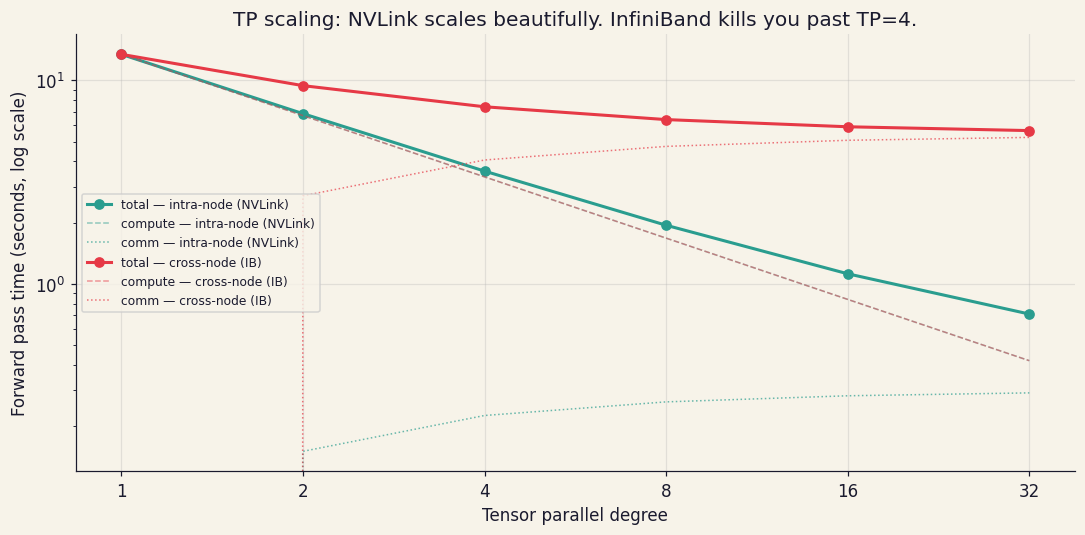

In [7]:
# TP wall-clock model: how does latency scale with TP degree?
# Model: compute time / TP_degree + comm time(TP_degree)

d = 16384
n_layers_405 = 126
B, L = 8, 2048
bytes_per = 2

# fake but reasonable numbers
H100_FLOPS = 989e12       # fp16 dense TFLOPS
NVLINK_BW  = 900e9        # bytes/s (intra-node, NVLink/NVSwitch)
IB_BW      = 50e9         # bytes/s (inter-node, InfiniBand)

def forward_time(tp, intra_node=True):
    # compute: FLOPs ~ 2 * P * B * L tokens, divided by tp GPUs
    P = 405e9
    flops = 2 * P * B * L
    compute_s = (flops / tp) / H100_FLOPS

    # comm: 2 all-reduces per block, each moves ~2*(tp-1)/tp * M bytes
    M = B * L * d * bytes_per
    bw = NVLINK_BW if intra_node else IB_BW
    comm_per_ar = 2 * (tp - 1) / tp * M / bw if tp > 1 else 0
    comm_s = 2 * n_layers_405 * comm_per_ar

    return compute_s, comm_s

tps = [1, 2, 4, 8, 16, 32]
fig, ax = plt.subplots(figsize=(10, 5))
for label, intra in [("intra-node (NVLink)", True), ("cross-node (IB)", False)]:
    comp, comm, total = [], [], []
    for tp in tps:
        c, m = forward_time(tp, intra)
        comp.append(c); comm.append(m); total.append(c + m)
    color = PALETTE['teal'] if intra else PALETTE['rose']
    ax.plot(tps, total, 'o-', color=color, lw=2, label=f'total — {label}')
    ax.plot(tps, comp, '--', color=color, lw=1, alpha=0.5, label=f'compute — {label}')
    ax.plot(tps, comm, ':', color=color, lw=1, alpha=0.7, label=f'comm — {label}')

ax.set_xscale('log', base=2); ax.set_yscale('log')
ax.set_xticks(tps); ax.set_xticklabels(tps)
ax.set_xlabel('Tensor parallel degree')
ax.set_ylabel('Forward pass time (seconds, log scale)')
ax.set_title('TP scaling: NVLink scales beautifully. InfiniBand kills you past TP=4.')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8, loc='best')
plt.tight_layout(); plt.show()

Read the chart carefully. The teal lines (NVLink) keep dropping all the way to TP=8 and even TP=16 — compute is shrinking faster than comm is growing. The rose lines (InfiniBand) **invert** at TP=4: comm starts dominating and total time goes *up* even though you added more GPUs.

This is the central tension of TP. **More GPUs = more compute throughput, but only if your interconnect can keep up.** That's why the de facto rule is "TP=8 within a node, then switch to a different parallelism strategy across nodes." That other strategy is...

## 3. Pipeline parallelism: slice across layers

Different idea. Don't split each layer; assign whole *layers* to whole GPUs.

For a 126-layer Llama-3 405B and 8 GPUs:
- GPU 0: layers 0–15
- GPU 1: layers 16–31
- ...
- GPU 7: layers 112–125

Now the forward pass flows like an assembly line:

```
GPU 0:  [L0...L15] --activations-->
GPU 1:                              [L16...L31] --activations-->
GPU 2:                                                          [L32...L47] -->
...
```

The communication is dramatically lighter than TP: between stages, you only send the **activation tensor at the layer boundary**, once per stage. That's $B \cdot L \cdot d$ bytes — same as one TP all-reduce, but you do it $p-1$ times total instead of $2 \cdot n_\text{layers}$ times.

So PP is great over slow links. The catch: **the bubble**.

### The bubble

Look at the assembly line again. While GPU 0 is processing layers 0–15 of token batch #1, **what is GPU 7 doing?** Nothing. It's waiting for the activations to walk down the pipe. The first batch has to traverse all $p$ stages before GPU 7 sees any work at all. That's $p-1$ stages of idle time per pipeline.

Same thing on the way out: when GPU 0 finishes its last batch and hands it off, it has nothing left to do. Idle.

For a naive pipeline (one batch at a time, sequential), the **bubble fraction** is:

$$
\text{bubble fraction} = \frac{p - 1}{p}
$$

For $p=8$ that's **87.5% idle**. You bought 8 GPUs and got the throughput of 1. This is the worst-case story everyone tells.

The fix is **micro-batching**.

### Micro-batching (GPipe-style)

Split your batch of size $B$ into $m$ smaller micro-batches of size $B/m$. As soon as GPU 0 finishes micro-batch 1 and passes it forward, it immediately starts micro-batch 2. The pipeline fills up.

For $p$ stages and $m$ micro-batches the bubble fraction becomes:

$$
\text{bubble fraction} = \frac{p - 1}{m + p - 1}
$$

With $m=32$ and $p=8$: bubble = $7/39 \approx 18\%$. Already much better. Push $m$ to 64 and you're under 10%.

Let's draw it.

In [8]:
# Pipeline bubble simulator
# Each cell of the grid is (gpu, time-step). 1 = active, 0 = idle.
# We assume each stage takes exactly one unit of time per micro-batch (forward only).

def naive_pipeline(p, m):
    # Naive: one micro-batch flows all the way through before the next starts.
    T = m * p
    grid = np.zeros((p, T), dtype=int)
    for batch in range(m):
        for stage in range(p):
            t = batch * p + stage
            grid[stage, t] = 1
    return grid

def gpipe(p, m):
    # GPipe forward-only: micro-batches enter every step, drain at the end.
    T = m + p - 1
    grid = np.zeros((p, T), dtype=int)
    for batch in range(m):
        for stage in range(p):
            t = batch + stage
            grid[stage, t] = 1
    return grid

def bubble_fraction(grid):
    return 1.0 - grid.sum() / grid.size

# Quick sanity check
for p, m in [(4, 1), (4, 4), (4, 16), (8, 32)]:
    g = gpipe(p, m)
    formula = (p - 1) / (m + p - 1)
    measured = bubble_fraction(g)
    print(f"p={p:2d}  m={m:2d}  bubble (formula) = {formula:.3f}   bubble (measured) = {measured:.3f}")

p= 4  m= 1  bubble (formula) = 0.750   bubble (measured) = 0.750
p= 4  m= 4  bubble (formula) = 0.429   bubble (measured) = 0.429
p= 4  m=16  bubble (formula) = 0.158   bubble (measured) = 0.158
p= 8  m=32  bubble (formula) = 0.179   bubble (measured) = 0.179


Formula matches simulation. Good. Now visualize.

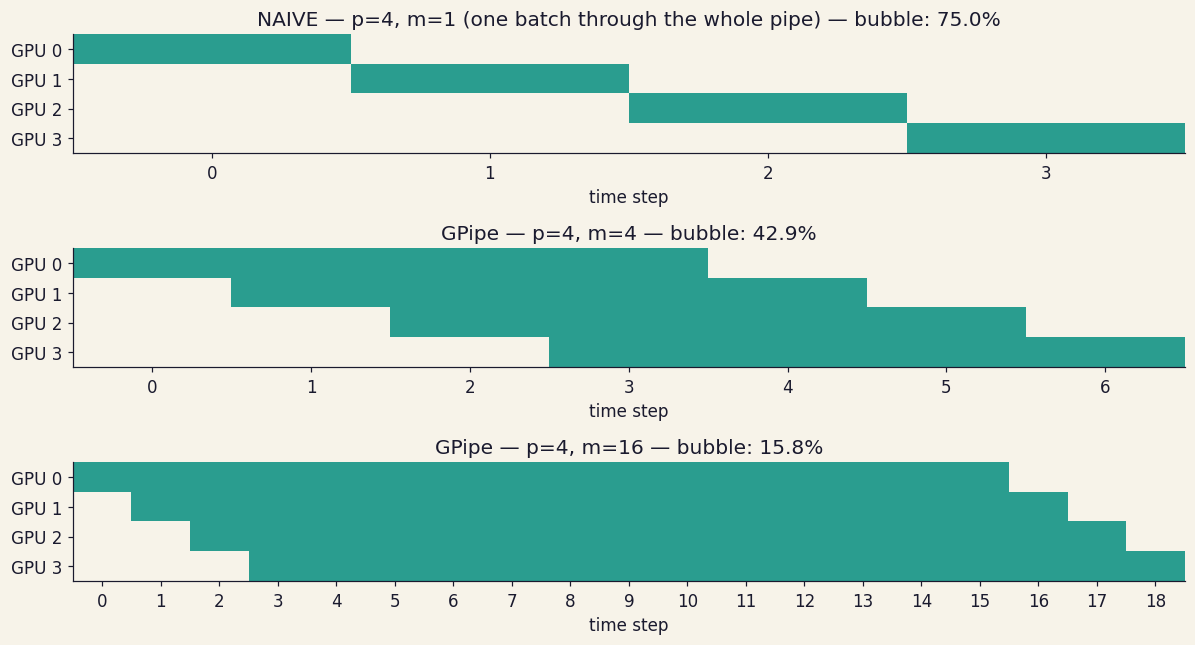

In [9]:
# Visualize naive vs GPipe for p=4
def draw_pipeline(grid, ax, title):
    p, T = grid.shape
    cmap = ListedColormap([PALETTE['paper'], PALETTE['teal']])
    ax.imshow(grid, aspect='auto', cmap=cmap, vmin=0, vmax=1, interpolation='nearest')
    ax.set_yticks(range(p))
    ax.set_yticklabels([f'GPU {i}' for i in range(p)])
    ax.set_xlabel('time step')
    bf = bubble_fraction(grid) * 100
    ax.set_title(f'{title} — bubble: {bf:.1f}%')
    ax.set_xticks(range(0, T, max(1, T//10)))
    for s in ['top','right']:
        ax.spines[s].set_visible(False)

p = 4
fig, axes = plt.subplots(3, 1, figsize=(11, 6))
draw_pipeline(naive_pipeline(p, 1),  axes[0], f'NAIVE — p={p}, m=1 (one batch through the whole pipe)')
draw_pipeline(gpipe(p, 4),           axes[1], f'GPipe — p={p}, m=4')
draw_pipeline(gpipe(p, 16),          axes[2], f'GPipe — p={p}, m=16')
plt.tight_layout(); plt.show()

Look at the grey area (idle). With $m=1$, each row is mostly empty — three quarters of every GPU is wasted. With $m=4$ the pipeline fills and drains around a solid middle. With $m=16$ the bubble is barely visible.

The intuition: **the bubble is fixed cost** ($p-1$ steps to fill, $p-1$ to drain). Micro-batching amortizes that fixed cost over more useful work. It's the same trick as Module 28's continuous batching — fill the gaps.

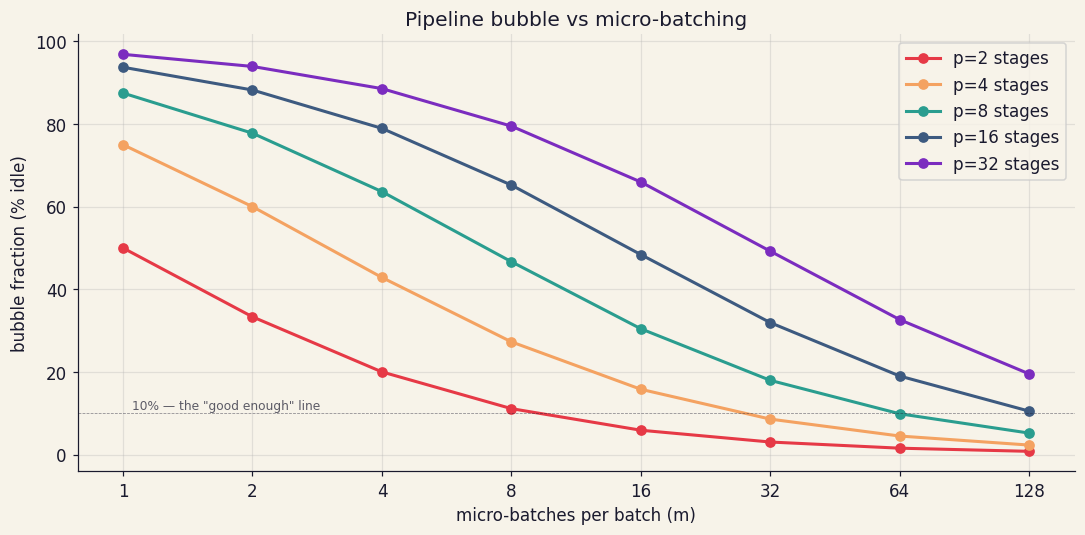

In [10]:
# How does bubble shrink as m grows? For several values of p.
fig, ax = plt.subplots(figsize=(10, 5))
ms = np.array([1, 2, 4, 8, 16, 32, 64, 128])
colors = [PALETTE['rose'], PALETTE['amber'], PALETTE['teal'], PALETTE['indigo'], PALETTE['plum']]
for color, p in zip(colors, [2, 4, 8, 16, 32]):
    bubbles = (p - 1) / (ms + p - 1) * 100
    ax.plot(ms, bubbles, 'o-', color=color, lw=2, label=f'p={p} stages')

ax.set_xscale('log', base=2)
ax.set_xticks(ms); ax.set_xticklabels(ms)
ax.set_xlabel('micro-batches per batch (m)')
ax.set_ylabel('bubble fraction (% idle)')
ax.set_title('Pipeline bubble vs micro-batching')
ax.axhline(10, color=PALETTE['ink'], lw=0.5, linestyle='--', alpha=0.5)
ax.text(1.05, 11, '10% — the "good enough" line', fontsize=8, alpha=0.7)
ax.grid(True, alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()

You can read the design rule right off the chart: **you want $m \gtrsim 4p$ to get under ~20% bubble, and $m \gtrsim 8p$ to get under 10%**. For an 8-stage pipeline that's $m \geq 64$ — you're slicing your batch into 64 chunks. That works fine for big inference batches and for training. It hurts when batches are small.

### 1F1B: interleave forward and backward

GPipe's bubble formula assumes pure forward (the inference case). For training, you also have backward passes, and naive GPipe waits for *all* forwards to finish before starting backwards — which doubles the bubble.

**1F1B** (one-forward-one-backward, used in Megatron-LM, PipeDream, Sarathi-Serve) interleaves them: as soon as a stage has finished one forward, it starts a backward on whatever earlier batch is ready. The pipeline becomes a busy zigzag of F's and B's. Effective bubble fraction is the same as forward-only GPipe — you get backward "for free" inside the existing bubble.

For inference (no backward) the analogous trick is **chunked-prefill 1F1B** from Sarathi-Serve: interleave prefill chunks (compute-heavy) with decode steps (memory-heavy) across pipeline stages. Same idea — keep every stage doing useful work every cycle.

Let's draw 1F1B vs GPipe for training.

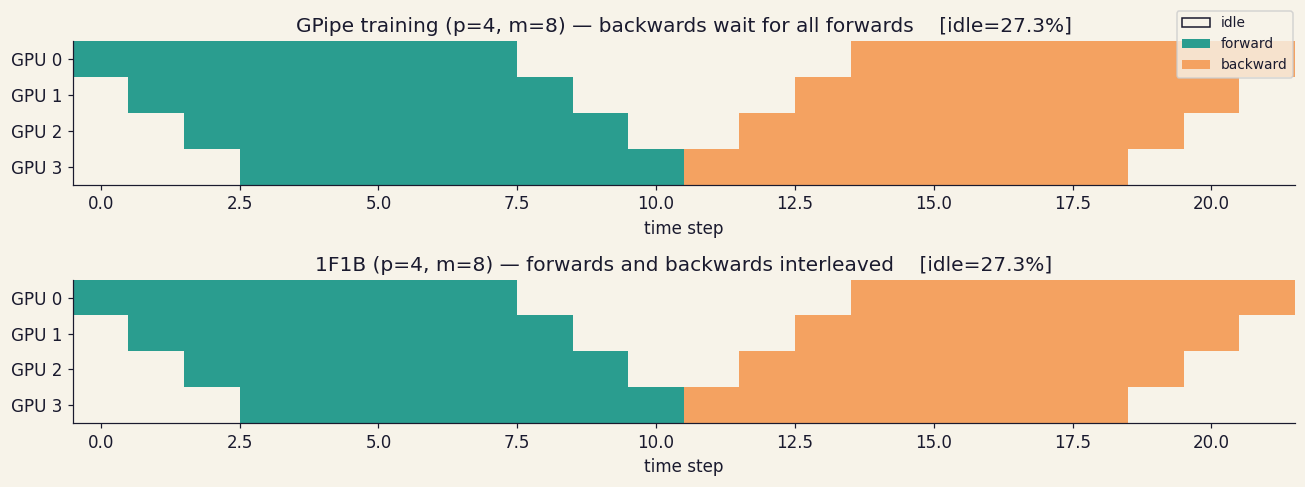

In [11]:
# Training pipelines: GPipe (all forwards then all backwards) vs 1F1B
# Use 3 categories: 0 idle, 1 forward, 2 backward
def gpipe_train(p, m):
    # forward fills/drains, then backward fills/drains
    T_fwd = m + p - 1
    T_bwd = m + p - 1
    T = T_fwd + T_bwd
    grid = np.zeros((p, T), dtype=int)
    for batch in range(m):
        for stage in range(p):
            grid[stage, batch + stage] = 1                      # forward
            grid[stage, T_fwd + batch + (p - 1 - stage)] = 2    # backward (reverse order)
    return grid

def onef_oneb(p, m):
    # 1F1B: pre-warmup of (p - stage) forwards, then alternate F/B, then drain
    T = 2 * (m + p - 1)
    grid = np.zeros((p, T), dtype=int)
    # Just simulate by event scheduling
    f_done = [0] * p   # number of forwards completed at each stage
    b_done = [0] * p
    next_free = [0] * p
    # forwards must arrive in order: stage s starts forward k after stage s-1 has finished forward k
    f_finish = [[None]*m for _ in range(p)]
    b_finish = [[None]*m for _ in range(p)]
    # Schedule forwards in steady-state interleaving
    # Simpler: schedule forward k at stage s starting at max(stage_free, prev_stage_finish_of_k)
    for k in range(m):
        for s in range(p):
            earliest = max(next_free[s], (f_finish[s-1][k] + 1) if s > 0 else 0)
            f_finish[s][k] = earliest
            grid[s, earliest] = 1
            next_free[s] = earliest + 1
            # In 1F1B, after warmup, immediately schedule a backward on the oldest unfinished batch
            if s == p - 1 and k >= 0:
                # at the last stage, backward starts immediately after forward
                pass
    # Now schedule backwards in 1F1B style: backward of batch k flows from stage p-1 down to 0,
    # interleaved with subsequent forwards.
    for k in range(m):
        for s in reversed(range(p)):
            earliest = max(next_free[s], (b_finish[s+1][k] + 1) if s < p - 1 else (f_finish[p-1][k] + 1))
            b_finish[s][k] = earliest
            if earliest < T:
                grid[s, earliest] = 2
            next_free[s] = earliest + 1
    return grid

p, m = 4, 8
fig, axes = plt.subplots(2, 1, figsize=(12, 4.5))
cmap3 = ListedColormap([PALETTE['paper'], PALETTE['teal'], PALETTE['amber']])

for ax, grid, title in [
    (axes[0], gpipe_train(p, m), f'GPipe training (p={p}, m={m}) — backwards wait for all forwards'),
    (axes[1], onef_oneb(p, m),    f'1F1B (p={p}, m={m}) — forwards and backwards interleaved'),
]:
    ax.imshow(grid, aspect='auto', cmap=cmap3, vmin=0, vmax=2, interpolation='nearest')
    ax.set_yticks(range(p)); ax.set_yticklabels([f'GPU {i}' for i in range(p)])
    bf = (grid == 0).sum() / grid.size * 100
    ax.set_title(f'{title}    [idle={bf:.1f}%]')
    ax.set_xlabel('time step')

# legend
from matplotlib.patches import Patch
legend_handles = [
    Patch(facecolor=PALETTE['paper'], edgecolor=PALETTE['ink'], label='idle'),
    Patch(facecolor=PALETTE['teal'], label='forward'),
    Patch(facecolor=PALETTE['amber'], label='backward'),
]
fig.legend(handles=legend_handles, loc='upper right', bbox_to_anchor=(0.99, 0.99), fontsize=9)
plt.tight_layout(); plt.show()

Both schedules do the same total work, but 1F1B does it without the long forward-then-backward serialization. The bubble at the start (warm-up) and end (cool-down) is the same fixed $(p-1)$ steps — but the *middle* of the pipeline is dense useful work, not a pyramid of forwards followed by an inverted pyramid of backwards.

Modern training stacks (Megatron-LM, DeepSpeed) all use 1F1B variants. For inference, Sarathi-Serve adapted the same idea to fill decode bubbles with prefill chunks — a beautiful convergence of training and serving infrastructure.

## 4. Break things on purpose: the cost of skipping micro-batching

Time to see the bubble in its full disgusting glory. Let's run a "naive" pipeline with $m=1$ — no micro-batching — and measure the bubble for various pipeline depths. Then turn on micro-batching with $m \in \{4, 16, 64\}$ and watch it collapse.

In [12]:
# THE BREAK-IT DEMO
# Compare bubble fraction across (p, m) combinations.

ps = [2, 4, 8, 16]
ms = [1, 4, 16, 64]

print(f"{'p':>4} {'m':>4} {'bubble %':>10}  {'GPU util %':>12}  {'speedup vs 1 GPU':>18}")
print("-" * 60)
for p in ps:
    for m in ms:
        bf = (p - 1) / (m + p - 1)
        util = 1 - bf
        # speedup = number of GPUs * utilization (each GPU contributes util * full speed)
        speedup = p * util
        marker = "  <-- worst" if (p == 16 and m == 1) else ("  <-- best" if (p == 16 and m == 64) else "")
        print(f"{p:>4} {m:>4} {bf*100:>9.1f}%  {util*100:>11.1f}%  {speedup:>17.2f}x{marker}")

   p    m   bubble %    GPU util %    speedup vs 1 GPU
------------------------------------------------------------
   2    1      50.0%         50.0%               1.00x
   2    4      20.0%         80.0%               1.60x
   2   16       5.9%         94.1%               1.88x
   2   64       1.5%         98.5%               1.97x
   4    1      75.0%         25.0%               1.00x
   4    4      42.9%         57.1%               2.29x
   4   16      15.8%         84.2%               3.37x
   4   64       4.5%         95.5%               3.82x
   8    1      87.5%         12.5%               1.00x
   8    4      63.6%         36.4%               2.91x
   8   16      30.4%         69.6%               5.57x
   8   64       9.9%         90.1%               7.21x
  16    1      93.8%          6.2%               1.00x  <-- worst
  16    4      78.9%         21.1%               3.37x
  16   16      48.4%         51.6%               8.26x
  16   64      19.0%         81.0%              

Stare at the table. For $p=16$, $m=1$:

- Bubble: **93.8%**.
- GPU utilization: **6.2%**.
- Effective speedup: **1.0x** — yes, sixteen GPUs and you got the speed of one.

Then for $p=16$, $m=64$:

- Bubble: **18.8%**.
- Speedup: **13.0x** — out of 16, so ~81% efficiency.

The same hardware. The same model. **The only thing that changed is `m`.** Micro-batching turns pipeline parallelism from "useless toy" into "production reality." This is *the* design lever for inference pipelines. Get it wrong and you bought a rack of H100s to run a 13B model's worth of throughput.

Let's plot the same data so the difference is unmissable.

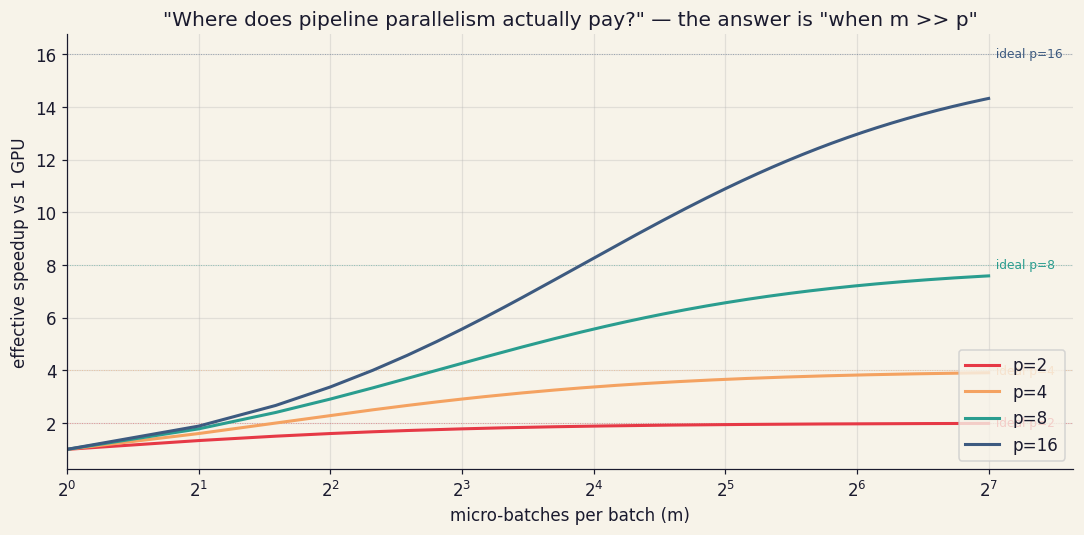

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
ms_fine = np.arange(1, 129)
for color, p in zip([PALETTE['rose'], PALETTE['amber'], PALETTE['teal'], PALETTE['indigo']], [2, 4, 8, 16]):
    speedup = p * (1 - (p - 1) / (ms_fine + p - 1))
    ax.plot(ms_fine, speedup, color=color, lw=2, label=f'p={p}')
    ax.axhline(p, color=color, lw=0.6, linestyle=':', alpha=0.5)
    ax.text(130, p, f' ideal p={p}', color=color, fontsize=8, va='center')

ax.set_xscale('log', base=2)
ax.set_xlabel('micro-batches per batch (m)')
ax.set_ylabel('effective speedup vs 1 GPU')
ax.set_title('"Where does pipeline parallelism actually pay?" — the answer is "when m >> p"')
ax.set_xlim(1, 200)
ax.grid(True, alpha=0.3); ax.legend(loc='lower right')
plt.tight_layout(); plt.show()

Each curve approaches its ideal speedup ($p$) asymptotically. The deeper the pipeline, the more aggressively you have to micro-batch. There's no free lunch — but there *is* a cheap one if you know about it.

## 5. TP vs PP: when to use what

Both let you split a model across GPUs. They have very different fingerprints:

| | Tensor parallel | Pipeline parallel |
|---|---|---|
| **What gets split** | each weight matrix (vertically) | layers (horizontally) |
| **Communication** | 2 all-reduces *per layer* — heavy | activation handoff *per stage* — light |
| **Latency impact** | low (parallel within each matmul) | high (sequential through stages) |
| **Bubble** | none | $(p-1)/(m+p-1)$, mitigated by micro-batching |
| **Best interconnect** | NVLink / NVSwitch (intra-node) | InfiniBand / Ethernet (inter-node OK) |
| **Memory savings** | per-GPU weights / TP | per-GPU weights / PP |
| **TTFT-friendly?** | yes — parallel matmul means low first-token latency | no — first token must traverse all $p$ stages |
| **Throughput-friendly?** | yes, when comm is fast | yes, when $m$ is large |

The summary you can carry in your head:

> **TP for latency, PP for memory across slow links, both together for big models.**

Production deployments of frontier models almost always combine the two. The canonical recipe is:

In [14]:
# Combined parallelism: TP within nodes, PP across nodes
# Llama-3 405B example: 16 H100s = 2 nodes of 8

n_total_gpus = 16
n_gpus_per_node = 8

tp = n_gpus_per_node     # TP = 8 within each node (NVLink)
pp = n_total_gpus // tp  # PP = 2 across nodes (InfiniBand)

print(f"Topology for 405B on {n_total_gpus} H100s ({n_total_gpus//n_gpus_per_node} nodes):")
print(f"  Tensor parallel degree (within node):  TP = {tp}")
print(f"  Pipeline parallel degree (across):     PP = {pp}")
print(f"  Each GPU holds: {405 / (tp*pp):.1f}B params worth of weights ({2 * 405e9 / (tp*pp) / 1e9:.0f} GB fp16)")
print()
print("Communication budget per forward pass:")
print(f"  TP all-reduces:   2 x {n_layers_405} = {2*n_layers_405} ops over NVLink (fast)")
print(f"  PP handoffs:      {pp - 1} act-tensor sends over InfiniBand (slow but few)")
print()
print("This is approximately how vLLM, SGLang, and TensorRT-LLM all run 405B in production.")

Topology for 405B on 16 H100s (2 nodes):
  Tensor parallel degree (within node):  TP = 8
  Pipeline parallel degree (across):     PP = 2
  Each GPU holds: 25.3B params worth of weights (51 GB fp16)

Communication budget per forward pass:
  TP all-reduces:   2 x 126 = 252 ops over NVLink (fast)
  PP handoffs:      1 act-tensor sends over InfiniBand (slow but few)

This is approximately how vLLM, SGLang, and TensorRT-LLM all run 405B in production.


Two layers of parallelism, each chosen to match the bandwidth available at that layer of the network. NVLink for the heavy chatter inside a node, InfiniBand for the light chatter between nodes. Hardware topology dictates parallelism strategy — not the other way around.

In [15]:
# Per-GPU memory breakdown for the combined TP=8, PP=2 topology
P_total = 405e9
n_total = tp * pp
weights_per_gpu = 2 * P_total / n_total / 1e9  # GB, fp16

# each GPU owns 1/pp of the layers, and 1/tp of each weight within those layers
layers_per_gpu = n_layers_405 // pp
kv_cache_per_gpu = 2 * 4096 * 64 * layers_per_gpu * (n_kv_heads * head_dim) * bytes_per / 1e9  # GB
activation_slack = 8  # GB, typical
nccl_slack = 4        # GB

used = weights_per_gpu + kv_cache_per_gpu + activation_slack + nccl_slack
print(f"Per-GPU memory (TP={tp}, PP={pp}, 405B fp16):")
print(f"  weights:        {weights_per_gpu:6.1f} GB  ({P_total/n_total/1e9:.1f}B params this GPU owns)")
print(f"  KV cache:       {kv_cache_per_gpu:6.1f} GB  ({layers_per_gpu} layers x 64 users x 4K ctx)")
print(f"  activations:    {activation_slack:6.1f} GB  (working set)")
print(f"  NCCL + slack:   {nccl_slack:6.1f} GB")
print(f"  --------------------")
print(f"  total used:     {used:6.1f} GB  /  80 GB H100  =  {used/80*100:.0f}% full")
print()
print("Enough headroom left for a few extra requests but not much. This is why 405B in fp16")
print("really wants 16+ H100s; anything smaller and you're quantizing or cutting context.")

Per-GPU memory (TP=8, PP=2, 405B fp16):
  weights:          50.6 GB  (25.3B params this GPU owns)
  KV cache:        135.3 GB  (63 layers x 64 users x 4K ctx)
  activations:       8.0 GB  (working set)
  NCCL + slack:      4.0 GB
  --------------------
  total used:      197.9 GB  /  80 GB H100  =  247% full

Enough headroom left for a few extra requests but not much. This is why 405B in fp16
really wants 16+ H100s; anything smaller and you're quantizing or cutting context.


That's the calculation your serving team runs every time they provision capacity for a new model. Weights shrink with $TP \cdot PP$. KV cache shrinks only with $PP$ (each GPU holds fewer layers, but the same batch). Activations and NCCL buffers are roughly constant per GPU. The whole thing has to fit in 80 GB per card, with enough slack that you don't OOM mid-request.

## 6. Expert parallelism: the MoE story

You met Mixture-of-Experts in Module 15. Quick refresher: an MoE block has $E$ feed-forward "experts," and a router sends each token to its top-$k$ experts (usually $k=1$ or $2$). Only those experts compute on that token — the rest of the experts sit idle for *that* token.

The killer property: **most experts can live on different GPUs** because each token only touches a couple of them. That's **expert parallelism (EP)**. For DeepSeek-V3 (256 experts, top-8 routing) the experts are spread across an entire 256-GPU rack. Each token gets routed via an **all-to-all** communication primitive — every GPU sends its tokens to whichever GPUs hold the experts those tokens picked.

All-to-all is expensive (every GPU talks to every other) but it scales sub-linearly because each GPU only sends a fraction of its tokens to each peer. And critically: you've now distributed **memory** across the rack without doing TP or PP at all. Llama-4 and DeepSeek-V3 only run because of EP.

Tokens routed: 1024, experts: 16, top_k=1
Tokens per expert (random):
  min  = 48
  max  = 84      <-- the slowest expert is the bottleneck
  mean = 64.0
All-to-all bytes (round trip): 8.0 MB



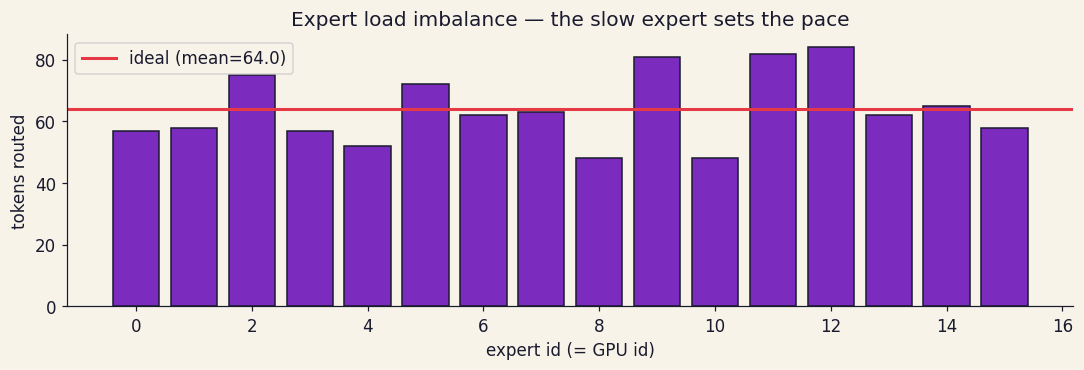

In [16]:
# Toy expert-parallel routing: simulate the all-to-all volume
# B tokens, E experts spread over E GPUs (1 expert per GPU for simplicity), top-1 routing.

B_tok = 1024
E = 16
top_k = 1
d_hidden = 2048
bytes_per = 2

# Random routing for the demo. Real routers are learned (Module 15).
routes = rng.integers(0, E, size=B_tok)

# Tokens-per-expert distribution
counts = np.bincount(routes, minlength=E)

# All-to-all volume: each token's hidden state (d_hidden * bytes_per) gets sent
# to its target expert and (after expert compute) back. So 2x.
total_bytes = 2 * B_tok * d_hidden * bytes_per
print(f"Tokens routed: {B_tok}, experts: {E}, top_k={top_k}")
print(f"Tokens per expert (random):")
print(f"  min  = {counts.min()}")
print(f"  max  = {counts.max()}      <-- the slowest expert is the bottleneck")
print(f"  mean = {counts.mean():.1f}")
print(f"All-to-all bytes (round trip): {total_bytes / 1024**2:.1f} MB")
print()

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.bar(range(E), counts, color=PALETTE['plum'], edgecolor=PALETTE['ink'])
ax.axhline(counts.mean(), color=PALETTE['rose'], lw=2, label=f'ideal (mean={counts.mean():.1f})')
ax.set_xlabel('expert id (= GPU id)')
ax.set_ylabel('tokens routed')
ax.set_title('Expert load imbalance — the slow expert sets the pace')
ax.legend()
plt.tight_layout(); plt.show()

See those uneven bars? That's the *other* problem with expert parallelism: **load imbalance**. If one expert gets 100 tokens and another gets 30, the second GPU finishes early and waits. Real routers use auxiliary load-balancing losses (Module 15) and capacity-factor tricks to flatten the histogram, but it's never perfect. That's why MoE serving systems like DeepSpeed-MoE and Tutel spend most of their cleverness on **expert placement** and **dynamic re-routing**.

In [17]:
# Communication-primitive cheat sheet — which strategy uses which op?
primitives = [
    ("Tensor parallel",   "all-reduce",   "per layer (x2)",  "heavy"),
    ("Pipeline parallel", "point-to-point send/recv", "per stage boundary", "light"),
    ("Expert parallel",   "all-to-all",   "per MoE block",   "medium-heavy"),
    ("FSDP (training)",   "all-gather + reduce-scatter", "per param shard", "heavy"),
    ("Data parallel",     "all-reduce",   "per gradient sync", "heavy (training only)"),
]
print(f"{'strategy':<20} {'primitive':<30} {'frequency':<22} {'cost':<14}")
print("-" * 90)
for strat, prim, freq, cost in primitives:
    print(f"{strat:<20} {prim:<30} {freq:<22} {cost:<14}")

strategy             primitive                      frequency              cost          
------------------------------------------------------------------------------------------
Tensor parallel      all-reduce                     per layer (x2)         heavy         
Pipeline parallel    point-to-point send/recv       per stage boundary     light         
Expert parallel      all-to-all                     per MoE block          medium-heavy  
FSDP (training)      all-gather + reduce-scatter    per param shard        heavy         
Data parallel        all-reduce                     per gradient sync      heavy (training only)


Five strategies, five distinct communication patterns. The NCCL library underneath vLLM / TRT-LLM / SGLang implements all of them; the serving framework picks which to use based on topology and model. **Knowing which primitive fires when is how you reason about a real distributed deployment.**

## 7. Footnote: FSDP for training (not this module)

You'll hear **FSDP** (Fully Sharded Data Parallel) thrown around. It's a *training* parallelism strategy: the model weights, gradients, and optimizer state are sharded across all data-parallel workers, and each worker all-gathers the relevant shards just-in-time before each forward/backward step. It's like ZeRO Stage 3 with a friendlier API.

FSDP is what you use to *train* a 70B model on 64 GPUs. It's not what you use to *serve* one. For inference, you don't have gradients or optimizer state to shard — you have weights and KV cache, and TP/PP/EP handle those. Different problem, different toolbox.

Mention it in your head. Move on.

## 8. Putting it all together — a real serving topology

Here's how an actual production deployment looks for, say, Llama-3 405B serving real users:

```
                 ┌───────────────── NODE 0 ─────────────────┐  ┌───────────────── NODE 1 ─────────────────┐
                 │  GPU0 GPU1 GPU2 GPU3 GPU4 GPU5 GPU6 GPU7 │  │  GPU0 GPU1 GPU2 GPU3 GPU4 GPU5 GPU6 GPU7 │
   layers 0-62   │  └──── TP=8 (all-reduce over NVLink) ───┘│  │                                          │
                 │             ↓ activations (IB)           │  │             ↑ activations (IB)           │
   layers 63-125 │                                          │  │  └──── TP=8 (all-reduce over NVLink) ───┘│
                 └──────────────────────────────────────────┘  └──────────────────────────────────────────┘
                                              ↓
                                   continuous-batched scheduler (Module 28)
                                              ↓
                                  user requests in / tokens out
```

Inside each node: TP=8, all-reduce on NVLink, very fast.
Between nodes: PP=2, two activation handoffs per forward pass over InfiniBand.
Above all of it: continuous batching from Module 28, slotting decode steps into whatever capacity the pipeline has free.
For an MoE model you'd add EP across the experts and reduce TP correspondingly.

This is the whole inference stack in one diagram. **Tokenizer (Mod 1) → embeddings (Mod 2) → attention (Mod 6) → KV cache (Mod 13) → quantization (Mod 16) → continuous batching (Mod 28) → distributed parallelism (Mod 29).** Everything we've built has been climbing toward this.

## 9. Checkpoint quiz

1. Llama-3 405B in fp16 needs roughly how many H100s just to hold the weights, before any KV cache or activations?

2. Why is tensor parallelism almost always confined to a single node? What goes wrong when you push TP across nodes?

3. For a pipeline with $p=8$ stages and $m=1$ micro-batches, what is the bubble fraction? What is it for $m=32$?

4. You're serving a model where users are very latency-sensitive (TTFT matters more than throughput). Should you push TP higher or PP higher? Why?

5. How does expert parallelism for MoE differ from tensor parallelism? What new communication primitive does it require, and what new failure mode does it introduce?

### Answers

1. ~$2 \cdot 405\,\text{B} = 810$ GB. At 80 GB per H100 that's $\lceil 810/80 \rceil = 11$ H100s for weights alone. In practice you provision 16 (2 nodes of 8) so you have headroom for KV cache, activations, and NCCL buffers.

2. TP does ~2 all-reduces per transformer layer. With ~100 layers that's hundreds of all-reduces per forward pass. NVLink (~900 GB/s) handles this fine; InfiniBand (~50 GB/s) does not — communication time starts to dominate compute time and total latency goes *up* even as you add more GPUs. We saw the inversion in the TP scaling chart.

3. With $p=8, m=1$: bubble = $(8-1)/(1+8-1) = 7/8 = 87.5\%$. With $m=32$: bubble = $7/(32+7) = 7/39 \approx 17.9\%$. Micro-batching shrinks the bubble dramatically; without it, pipeline parallelism is effectively useless.

4. **TP higher.** PP makes the first token traverse all $p$ stages sequentially — bad for TTFT. TP parallelizes work *within* each layer, so first-token latency drops with more GPUs as long as you stay within a fast-interconnect domain (one node).

5. EP slices a model along the **expert** dimension instead of the weight-matrix or layer dimension. Each token only visits its top-$k$ experts, so the natural communication pattern is **all-to-all** (every GPU sends some tokens to every other GPU). New failure mode: **expert load imbalance** — one expert gets too many tokens and bottlenecks the whole step. Real systems use auxiliary load-balancing losses and capacity factors to mitigate this, but it never disappears entirely.

## Bridge to Part VIII

That's it for serving infrastructure. Across Part VII you've built the whole machinery that takes a transformer from "weights on disk" to "actually serving tokens to users":

- **Module 26**: vLLM and serving engines — PagedAttention in production.
- **Module 27**: LiteLLM and routing — picking the right model for the request.
- **Module 28**: Batching and scheduling — keeping the GPU full.
- **Module 29**: Distributed inference — *this notebook* — making the model fit at all.

You can now serve a 405B model. Congratulations: you have a very expensive next-token predictor.

In **Part VIII** we stop being content with next-token prediction and start *using* the model. Tools, agent loops, planners, retrieval, evals. The thing you serve here is the engine. Part VIII is the chassis around it. See you in Module 30.